# Fixed-Alpha Rayleigh-Only and PINN-Rayleigh Demo

This notebook demonstrates two neural formulations for the reduced radial square-well Schr\u00f6dinger problem with a fixed exponential ansatz parameter $\alpha=0.25~\mathrm{fm}^{-1}$:

1. Rayleigh-only variational training.
2. PINN-Rayleigh training with a gradient-based learning schedule.

The notebook is self-contained and does not import `code/square_well.py`. It defines the physics, exact finite-box reference solution, neural network, samplers, losses, training loops, validation metrics, and plots directly here.

## Task 1. Define the Mathematical Problem and Exact Reference Solution

We solve the reduced radial $s$-wave Schr\u00f6dinger equation on the finite interval $r\in[0,r_{\max}]$:

$$-K u''(r) + V(r)u(r)=E u(r),\qquad K=\frac{\hbar^2}{2m},$$

where $u(r)=r\psi(r)$ and

$$V(r)=\begin{cases}-V_0,&0\le r\le R,\\0,&r>R.\end{cases}$$

The finite-box boundary conditions are $u(0)=0$ and $u(r_{\max})=0$. For a bound state $E<0$, the analytic square-well solution has the form

$$u(r)=A\sin(kr),\quad r\le R,$$

$$u(r)=B\sinh(q(r_{\max}-r)),\quad R<r\le r_{\max},$$

with $k=\sqrt{(E+V_0)/K}$ and $q=\sqrt{-E/K}$. Continuity of the logarithmic derivative at $r=R$ gives

$$k\cot(kR)+q\coth(q(r_{\max}-R))=0.$$

The following cell defines the physical constants, solves this matching equation, normalizes the exact solution, and plots the reference $u(r)$.

Reduced mass m = 469.459775 MeV
K = hbar^2/(2m) = 41.471013 MeV fm^2
Finite-box exact energy = -3.038467238 MeV


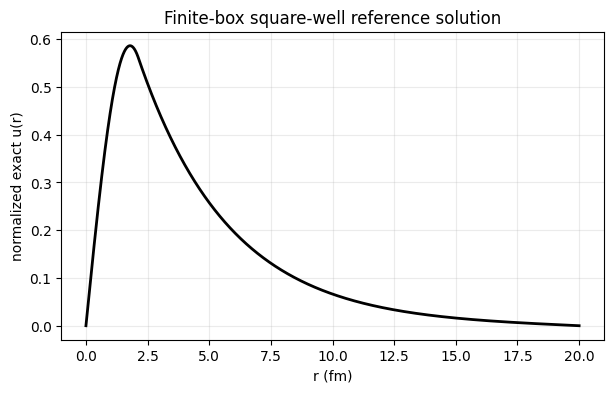

In [ ]:
from dataclasses import dataclass
from pathlib import Path
import math
import random
import sys
import os

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from soap import SOAP

#ROOT = Path.cwd()
#if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
#    ROOT = ROOT.parent
#RESULTS = ROOT / 'results'
#RESULTS.mkdir(exist_ok=True)

# Optional: use the same local SOAP optimizer as the scripts when available.
# The notebook does not import code/square_well.py.
#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))
#try:
#    from soap import SOAP
#except Exception:
#    SOAP = None

MP_MEV = 938.27
MN_MEV = 939.57
HBAR_MEV_FM = 197.327
M_REDUCED = (MP_MEV * MN_MEV) / (MP_MEV + MN_MEV)
K = HBAR_MEV_FM ** 2 / (2.0 * M_REDUCED)

V0 = 35.0
R0 = 2.13
R_MAX = 20.0
ALPHA_FIXED = 0.25

def match_function(E, v0=V0, radius=R0, r_max=R_MAX):
    k = np.sqrt((E + v0) / K)
    q = np.sqrt(-E / K)
    return k / np.tan(k * radius) + q / np.tanh(q * (r_max - radius))

def bisect_root(f, a, b, tol=1e-13, max_iter=200):
    fa, fb = f(a), f(b)
    if not np.isfinite(fa) or not np.isfinite(fb) or fa * fb > 0:
        raise ValueError('Invalid bracketing interval')
    for _ in range(max_iter):
        c = 0.5 * (a + b)
        fc = f(c)
        if abs(fc) < tol or 0.5 * (b - a) < tol:
            return c
        if fa * fc <= 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return 0.5 * (a + b)

def square_well_box_energy():
    # Scan for sign changes while skipping tangent singularities.
    grid = np.linspace(-V0 + 1e-8, -1e-8, 20000)
    vals = np.array([match_function(E) for E in grid])
    roots = []
    for a, b, fa, fb in zip(grid[:-1], grid[1:], vals[:-1], vals[1:]):
        if not (np.isfinite(fa) and np.isfinite(fb)):
            continue
        if abs(fa) > 1e4 or abs(fb) > 1e4:
            continue
        if fa == 0 or fa * fb < 0:
            try:
                roots.append(bisect_root(match_function, a, b))
            except ValueError:
                pass
    roots = sorted(set(round(x, 12) for x in roots))
    if not roots:
        raise RuntimeError('No finite-box bound-state root found')
    return min(roots)

E_BOX = square_well_box_energy()

def exact_u_numpy(r, E=E_BOX):
    r = np.asarray(r)
    k = np.sqrt((E + V0) / K)
    q = np.sqrt(-E / K)
    u = np.empty_like(r, dtype=float)
    inside = r <= R0
    u[inside] = np.sin(k * r[inside])
    continuity = np.sin(k * R0) / np.sinh(q * (R_MAX - R0))
    u[~inside] = continuity * np.sinh(q * (R_MAX - r[~inside]))
    norm = np.sqrt(np.trapezoid(u * u, r))
    return u / norm

r_ref = np.linspace(0.0, R_MAX, 8192)
u_ref = exact_u_numpy(r_ref)

print(f'Reduced mass m = {M_REDUCED:.6f} MeV')
print(f'K = hbar^2/(2m) = {K:.6f} MeV fm^2')
print(f'Finite-box exact energy = {E_BOX:.9f} MeV')

plt.figure(figsize=(7, 4))
plt.plot(r_ref, u_ref, color='black', lw=2)
plt.xlabel('r (fm)')
plt.ylabel('normalized exact u(r)')
plt.title('Finite-box square-well reference solution')
plt.grid(alpha=0.25)
plt.show()

## Task 2. Create the Neural Network Model and Training Set

We approximate the reduced radial function by the fixed-alpha ansatz

$$u_\theta(r)=r e^{-\alpha r}N_\theta(r),\qquad \alpha=0.25~\mathrm{fm}^{-1}.$$

The prefactor enforces $u_\theta(0)=0$ and encourages decay. The network input is scaled from $r\in[0,20]$ to $[-1,1]$ before it enters a small tanh MLP.

The PDE residual samples use a mixture distribution: uniform samples on the full interval, extra samples near the origin, and extra samples near the square-well discontinuity. The Rayleigh and normalization integrals use independent uniform random samples over the full interval and are resampled at every training step.

In [ ]:
def set_seed(seed=1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def inverse_softplus(x):
    return x + math.log(-math.expm1(-x))

class FixedAlphaRadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=ALPHA_FIXED, energy_init=-2.0):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)
        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy_raw = nn.Parameter(torch.tensor([inverse_softplus(-energy_init)], dtype=torch.float32))

    @property
    def energy(self):
        return -torch.nn.functional.softplus(self.energy_raw).squeeze()

    def forward(self, r):
        x = 2.0 * r / R_MAX - 1.0
        return r * torch.exp(-self.alpha * r) * self.net(x)

def potential_torch(r):
    return torch.where(r <= R0, torch.full_like(r, -V0), torch.zeros_like(r))

@dataclass
class TrainConfig:
    n_interior: int = 1280
    n_origin: int = 320
    n_interface: int = 640
    n_rayleigh: int = 2048
    origin_width: float = 0.5
    interface_width: float = 0.2
    lambda_rayleigh: float = 1.0
    lambda_norm: float = 10.0
    lambda_boundary: float = 10.0
    lambda_pde_cap: float = 0.1
    lambda_match_cap: float = 0.5
    warmup_steps: int = 2000
    ramp_steps: int = 3000
    grad_balance_every: int = 25
    grad_balance_ema: float = 0.8
    grad_balance_pde_scale: float = 0.5
    grad_balance_match_scale: float = 0.5
    grad_balance_min: float = 1e-4
    grad_balance_eps: float = 1e-12

cfg = TrainConfig()

def sample_pde_points(cfg, device, dtype):
    pts = [torch.rand(cfg.n_interior, 1, device=device, dtype=dtype) * R_MAX]
    pts.append(torch.rand(cfg.n_origin, 1, device=device, dtype=dtype) * cfg.origin_width)
    lo, hi = R0 - cfg.interface_width, R0 + cfg.interface_width
    pts.append(lo + (hi - lo) * torch.rand(cfg.n_interface, 1, device=device, dtype=dtype))
    r = torch.cat(pts, dim=0)
    r.requires_grad_(True)
    return r

def sample_uniform_rayleigh(n, device, dtype):
    r = torch.rand(n, 1, device=device, dtype=dtype) * R_MAX
    r.requires_grad_(True)
    return r, R_MAX / n

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f'Using device: {device}')
print(f'PDE samples per step: {cfg.n_interior + cfg.n_origin + cfg.n_interface}')
print(f'Rayleigh samples per step: {cfg.n_rayleigh}')

Using device: cpu
PDE samples per step: 2240
Rayleigh samples per step: 2048


## Task 3a. Formulate the Rayleigh-Only Loss

The Rayleigh-only objective minimizes the variational energy with normalization and finite-box boundary penalties:

$$\mathcal{L}_{\mathrm{R-only}}=\mathcal{E}_\theta+\lambda_{\mathrm{norm}}(\int u_\theta^2dr-1)^2+\lambda_D u_\theta(r_{\max})^2.$$

The energy appearing in the reported result is the Rayleigh quotient itself:

$$\mathcal{E}_\theta=\frac{\int_0^{r_{\max}} K|u_\theta'|^2+V|u_\theta|^2\,dr}{\int_0^{r_{\max}} |u_\theta|^2\,dr}.$$

No trainable energy parameter is used by this loss.

In [ ]:
def rayleigh_terms(model, cfg, device, dtype):
    r, w = sample_uniform_rayleigh(cfg.n_rayleigh, device, dtype)
    u = model(r)
    du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    v = potential_torch(r)
    norm = w * torch.sum(u.squeeze() ** 2)
    kinetic = w * torch.sum(K * du.squeeze() ** 2)
    potential = w * torch.sum(v.squeeze() * u.squeeze() ** 2)
    energy = (kinetic + potential) / torch.clamp(norm, min=1e-12)
    norm_loss = (norm - 1.0) ** 2
    r_boundary = torch.tensor([[R_MAX]], device=device, dtype=dtype, requires_grad=True)
    boundary_loss = model(r_boundary).squeeze() ** 2
    return {
        'rayleigh_energy': energy,
        'norm_value': norm,
        'kinetic': kinetic,
        'potential': potential,
        'norm_loss': norm_loss,
        'boundary_loss': boundary_loss,
    }

def rayleigh_only_loss(model, cfg, device, dtype):
    t = rayleigh_terms(model, cfg, device, dtype)
    loss = (
        cfg.lambda_rayleigh * t['rayleigh_energy']
        + cfg.lambda_norm * t['norm_loss']
        + cfg.lambda_boundary * t['boundary_loss']
    )
    return loss, t

## Task 3b. Formulate the PINN-Rayleigh Loss

The PINN-Rayleigh objective augments the Rayleigh variational objective with a PDE residual and an energy-consistency penalty:

$$\mathcal{L}_{\mathrm{PINN-R}}=\mathcal{E}_\theta+\lambda_{\mathrm{pde}}\langle|-K u_\theta''+Vu_\theta-E_\theta u_\theta|^2\rangle+\lambda_{\mathrm{match}}(E_\theta-\mathcal{E}_\theta)^2+\lambda_{\mathrm{norm}}(\int u_\theta^2dr-1)^2+\lambda_Du_\theta(r_{\max})^2.$$

Here $E_\theta=-\mathrm{softplus}(E_{\mathrm{raw}})$ is learnable, while $\alpha=0.25~\mathrm{fm}^{-1}$ is fixed. The PDE samples and Rayleigh samples are resampled every step.

In [ ]:
def pde_residual_loss(model, cfg, device, dtype):
    r = sample_pde_points(cfg, device, dtype)
    u = model(r)
    du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    d2u = torch.autograd.grad(du, r, grad_outputs=torch.ones_like(du), create_graph=True, retain_graph=True)[0]
    residual = -K * d2u + potential_torch(r) * u - model.energy * u
    return torch.mean(residual ** 2)

def pinn_rayleigh_terms(model, cfg, device, dtype, compute_pde=True):
    t = rayleigh_terms(model, cfg, device, dtype)
    t['pde_loss'] = pde_residual_loss(model, cfg, device, dtype) if compute_pde else torch.zeros((), device=device, dtype=dtype)
    t['energy_consistency_loss'] = (model.energy - t['rayleigh_energy']) ** 2
    return t

def pinn_rayleigh_loss(model, cfg, device, dtype, lambda_pde, lambda_match):
    t = pinn_rayleigh_terms(model, cfg, device, dtype, compute_pde=lambda_pde > 0.0)
    loss = (
        cfg.lambda_rayleigh * t['rayleigh_energy']
        + lambda_pde * t['pde_loss']
        + lambda_match * t['energy_consistency_loss']
        + cfg.lambda_norm * t['norm_loss']
        + cfg.lambda_boundary * t['boundary_loss']
    )
    return loss, t

## Shared Training and Validation Utilities

The next cell defines reusable utilities used by both training tasks. Validation is performed on a fixed dense grid, independent of the random training samples. The model solution is normalized and sign-aligned with the exact solution before computing the $L^2$ error.

In [ ]:
def make_optimizer(model, lr=3e-3):
    if SOAP is not None:
        return SOAP(model.parameters(), lr=lr, betas=(0.95, 0.95), weight_decay=0.0, precondition_frequency=10)
    return torch.optim.Adam(model.parameters(), lr=lr)

def validate_model(model, label='model'):
    model.eval()
    r = torch.linspace(0.0, R_MAX, 8192, device=device, dtype=dtype).unsqueeze(1)
    r.requires_grad_(True)
    u = model(r)
    du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u = torch.autograd.grad(du, r, grad_outputs=torch.ones_like(du), create_graph=False)[0]
    v = potential_torch(r)
    rf = r.squeeze()
    uf = u.squeeze()
    duf = du.squeeze()
    norm = torch.trapezoid(uf ** 2, rf)
    kinetic = torch.trapezoid(K * duf ** 2, rf)
    potential = torch.trapezoid(v.squeeze() * uf ** 2, rf)
    energy = (kinetic + potential) / norm
    residual = -K * d2u.squeeze() + v.squeeze() * uf - model.energy.detach() * uf
    dense_pde = torch.mean(residual ** 2)

    r_np = rf.detach().cpu().numpy()
    u_np = uf.detach().cpu().numpy()
    u_exact = exact_u_numpy(r_np)
    u_norm = u_np / np.sqrt(max(np.trapezoid(u_np * u_np, r_np), 1e-30))
    if np.trapezoid(u_norm * u_exact, r_np) < 0:
        u_norm = -u_norm
    l2 = np.sqrt(np.trapezoid((u_norm - u_exact) ** 2, r_np))
    metrics = {
        'label': label,
        'rayleigh_energy': float(energy.detach().cpu()),
        'energy_error': abs(float(energy.detach().cpu()) - E_BOX),
        'l2_u_error': float(l2),
        'norm': float(norm.detach().cpu()),
        'pde_loss_dense': float(dense_pde.detach().cpu()),
        'u_rmax': float(uf[-1].detach().cpu()),
        'learned_energy': float(model.energy.detach().cpu()),
    }
    return metrics, r_np, u_norm, u_exact

def print_metrics(metrics):
    for key, value in metrics.items():
        if key == 'label':
            print(value)
        elif isinstance(value, float):
            print(f'  {key}: {value:.8g}')

def plot_solution(r, u_model, u_exact, title):
    plt.figure(figsize=(7, 4))
    plt.plot(r, u_exact, color='black', lw=2.2, label='exact finite-box solution')
    plt.plot(r, u_model, lw=1.8, label='neural solution')
    plt.xlabel('r (fm)')
    plt.ylabel('normalized u(r)')
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

## Task 4. Train the Rayleigh-Only Model

This task trains the fixed-alpha network using only the Rayleigh quotient plus normalization and finite-box boundary penalties. The trainable energy parameter exists in the model class for convenience, but it is not used in this loss and therefore should not be interpreted for this case. After training, the code recomputes the Rayleigh energy on a dense fixed grid, reports the energy and wavefunction errors, and plots $u_\theta(r)$ against the exact finite-box solution.

{'step': 1, 'loss': 10.508590698242188, 'rayleigh': 1.3466418981552124, 'norm': 0.04301504045724869}
{'step': 500, 'loss': -3.1792168617248535, 'rayleigh': -3.179523468017578, 'norm': 0.9984912872314453}
{'step': 1000, 'loss': -3.3701343536376953, 'rayleigh': -3.3876123428344727, 'norm': 0.9584707021713257}
{'step': 1500, 'loss': -3.3161773681640625, 'rayleigh': -3.330556631088257, 'norm': 1.037650465965271}
{'step': 2000, 'loss': -4.737405776977539, 'rayleigh': -4.746865749359131, 'norm': 0.9693245887756348}
{'step': 2500, 'loss': -2.622173547744751, 'rayleigh': -2.630483627319336, 'norm': 0.9714193344116211}
{'step': 3000, 'loss': -2.1799376010894775, 'rayleigh': -2.1885006427764893, 'norm': 0.9715474247932434}
{'step': 3500, 'loss': -4.461519718170166, 'rayleigh': -4.5145487785339355, 'norm': 1.0725964307785034}
{'step': 4000, 'loss': -3.9552533626556396, 'rayleigh': -3.9567086696624756, 'norm': 0.9883001446723938}
{'step': 4500, 'loss': -4.255769729614258, 'rayleigh': -4.3962044715

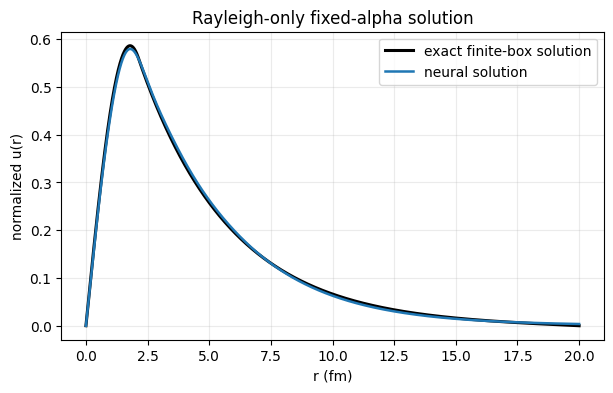

In [ ]:
def train_rayleigh_only(steps=10000, lr=3e-3, seed=1234):
    set_seed(seed)
    model = FixedAlphaRadialNet(alpha=ALPHA_FIXED).to(device=device, dtype=dtype)
    opt = make_optimizer(model, lr=lr)
    history = []
    for step in range(1, steps + 1):
        opt.zero_grad(set_to_none=True)
        loss, terms = rayleigh_only_loss(model, cfg, device, dtype)
        loss.backward()
        opt.step()
        if step == 1 or step % 500 == 0 or step == steps:
            row = {
                'step': step,
                'loss': float(loss.detach().cpu()),
                'rayleigh': float(terms['rayleigh_energy'].detach().cpu()),
                'norm': float(terms['norm_value'].detach().cpu()),
            }
            history.append(row)
            print(row)
    return model, history

rayleigh_model, rayleigh_history = train_rayleigh_only(steps=10000)
rayleigh_metrics, r_plot, u_rayleigh, u_exact_plot = validate_model(rayleigh_model, 'Rayleigh only')
print_metrics(rayleigh_metrics)
plot_solution(r_plot, u_rayleigh, u_exact_plot, 'Rayleigh-only fixed-alpha solution')

## Task 5. Train the PINN-Rayleigh Model with a Gradient-Based Learning Schedule

The PINN-Rayleigh loss can be difficult to weight manually because the Rayleigh term is an energy, while the PDE term is a squared residual. Here the Rayleigh term is treated as the anchor. During training, the PDE and energy-consistency weights are adjusted from gradient norms:

$$\lambda_i(t)\approx c_i\frac{\|\nabla_\theta\mathcal{E}_\theta\|}{\|\nabla_\theta\mathcal{L}_i\|+\epsilon},$$

where $\mathcal{L}_i$ is either the PDE residual loss or the energy-consistency loss. We also use a Rayleigh warmup: for the first 2000 steps the PDE and matching weights are zero, then their maximum allowed values ramp over 3000 steps to $\lambda_{\mathrm{pde}}\le0.1$ and $\lambda_{\mathrm{match}}\le0.5$. This lets the variational objective find the correct bound-state basin before the local PDE residual becomes active.

{'step': 1, 'loss': 10.508590698242188, 'rayleigh': 1.3466418981552124, 'E_theta': -2.0, 'lambda_pde': 0.0, 'lambda_match': 0.0, 'pde_loss': 0.0, 'match_loss': 11.200013160705566}
{'step': 500, 'loss': -3.1792168617248535, 'rayleigh': -3.179523468017578, 'E_theta': -2.0, 'lambda_pde': 0.0, 'lambda_match': 0.0, 'pde_loss': 0.0, 'match_loss': 1.3912756443023682}
{'step': 1000, 'loss': -3.3701343536376953, 'rayleigh': -3.3876123428344727, 'E_theta': -2.0, 'lambda_pde': 0.0, 'lambda_match': 0.0, 'pde_loss': 0.0, 'match_loss': 1.9254679679870605}
{'step': 1500, 'loss': -3.3161773681640625, 'rayleigh': -3.330556631088257, 'E_theta': -2.0, 'lambda_pde': 0.0, 'lambda_match': 0.0, 'pde_loss': 0.0, 'match_loss': 1.770380973815918}
{'step': 2000, 'loss': -4.737405776977539, 'rayleigh': -4.746865749359131, 'E_theta': -2.0, 'lambda_pde': 0.0, 'lambda_match': 0.0, 'pde_loss': 0.0, 'match_loss': 7.545271396636963}
{'step': 2500, 'loss': -1.4447576999664307, 'rayleigh': -1.6738204956054688, 'E_theta':

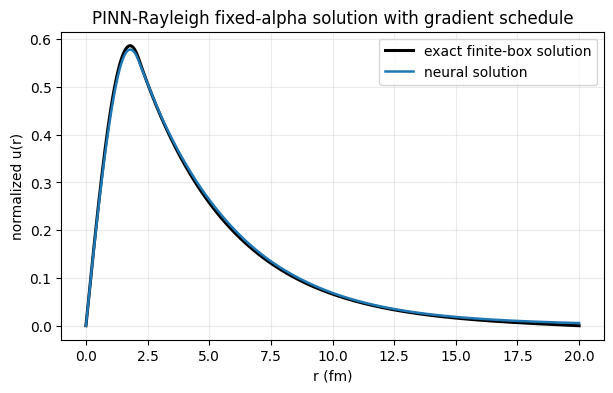

In [ ]:
def grad_norm(term, parameters):
    if not term.requires_grad:
        return 0.0
    grads = torch.autograd.grad(term, parameters, retain_graph=True, create_graph=False, allow_unused=True)
    total = torch.zeros((), device=term.device, dtype=term.dtype)
    for g in grads:
        if g is not None:
            total = total + g.detach().pow(2).sum()
    return float(torch.sqrt(total).cpu())

def schedule_caps(step, cfg):
    if step <= cfg.warmup_steps:
        progress = 0.0
    else:
        progress = min(1.0, (step - cfg.warmup_steps) / max(1, cfg.ramp_steps))
    return progress * cfg.lambda_pde_cap, progress * cfg.lambda_match_cap

def balanced_weight(anchor_norm, term_norm, cap, scale, cfg):
    if cap <= 0.0 or anchor_norm <= cfg.grad_balance_eps or term_norm <= cfg.grad_balance_eps:
        return 0.0
    raw = scale * anchor_norm / (term_norm + cfg.grad_balance_eps)
    return min(cap, max(min(cfg.grad_balance_min, cap), raw))

def train_pinn_rayleigh_grad_balance(steps=10000, lr=3e-3, seed=1234):
    set_seed(seed)
    model = FixedAlphaRadialNet(alpha=ALPHA_FIXED).to(device=device, dtype=dtype)
    opt = make_optimizer(model, lr=lr)
    params = [p for p in model.parameters() if p.requires_grad]
    lambda_pde = 0.0
    lambda_match = 0.0
    history = []

    for step in range(1, steps + 1):
        pde_cap, match_cap = schedule_caps(step, cfg)
        compute_pde = pde_cap > 0.0
        terms = pinn_rayleigh_terms(model, cfg, device, dtype, compute_pde=compute_pde)

        if step == 1 or step % cfg.grad_balance_every == 0:
            g_ray = grad_norm(terms['rayleigh_energy'], params)
            g_pde = grad_norm(terms['pde_loss'], params)
            g_match = grad_norm(terms['energy_consistency_loss'], params)
            next_pde = balanced_weight(g_ray, g_pde, pde_cap, cfg.grad_balance_pde_scale, cfg)
            next_match = balanced_weight(g_ray, g_match, match_cap, cfg.grad_balance_match_scale, cfg)
            ema = cfg.grad_balance_ema
            lambda_pde = next_pde if step == 1 else ema * lambda_pde + (1.0 - ema) * next_pde
            lambda_match = next_match if step == 1 else ema * lambda_match + (1.0 - ema) * next_match
        lambda_pde = min(pde_cap, max(0.0, lambda_pde))
        lambda_match = min(match_cap, max(0.0, lambda_match))

        loss = (
            cfg.lambda_rayleigh * terms['rayleigh_energy']
            + lambda_pde * terms['pde_loss']
            + lambda_match * terms['energy_consistency_loss']
            + cfg.lambda_norm * terms['norm_loss']
            + cfg.lambda_boundary * terms['boundary_loss']
        )
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step == 1 or step % 500 == 0 or step == steps:
            row = {
                'step': step,
                'loss': float(loss.detach().cpu()),
                'rayleigh': float(terms['rayleigh_energy'].detach().cpu()),
                'E_theta': float(model.energy.detach().cpu()),
                'lambda_pde': lambda_pde,
                'lambda_match': lambda_match,
                'pde_loss': float(terms['pde_loss'].detach().cpu()),
                'match_loss': float(terms['energy_consistency_loss'].detach().cpu()),
            }
            history.append(row)
            print(row)
    return model, history

pinn_model, pinn_history = train_pinn_rayleigh_grad_balance(steps=10000)
pinn_metrics, r_plot, u_pinn, u_exact_plot = validate_model(pinn_model, 'PINN-Rayleigh with gradient schedule')
print_metrics(pinn_metrics)
plot_solution(r_plot, u_pinn, u_exact_plot, 'PINN-Rayleigh fixed-alpha solution with gradient schedule')